In [ ]:
print("Hello from AI Cup")

Hello from AI Cup


In [ ]:
!echo hello

hello


In [ ]:
import numpy as np

In [ ]:
# import skyfield

# Let's load the data

In [ ]:
import pandas as pd

train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")

train_df = train_df.set_index("track_id")
test_df = test_df.set_index("track_id")

train_df

,timestamp_start_radar_utc,timestamp_end_radar_utc,trajectory,trajectory_time,radar_bird_size,airspeed,min_z,max_z,observation_id,primary_observation_id,observer_position,observer_comment,n_birds_observed,bird_group,bird_species
track_id,,,,,,,,,,,,,,,
2537685,2023-09-05 08:59:18,2023-09-05 09:00:52,01020000E0E61000005200000026EE676787321B403B57...,"[0.0, 1.01982, 2.03911, 3.05854, 4.07798, 5.09...",Small bird,16.30710,50.019,151.222,2214,2214,01010000A0E6100000509297E6A2381B407E2E588CE4BA...,NaN,1,Waders,Dunlin
2538937,2023-09-05 09:00:31,2023-09-05 09:02:25,01020000E0E6100000670000000364E067F9351B4030B8...,"[0.0, 1.01519, 2.02996, 4.06014, 5.07671, 7.10...",Small bird,10.78880,0.800,62.424,2215,2215,01010000A0E610000026926751A6301B40D0083ACC62BA...,NaN,1,Gulls,Black-headed Gull
2539560,2023-09-05 09:01:13,2023-09-05 09:03:36,01020000E0E61000007D00000040B7E1C160401B4045EC...,"[0.0, 2.02202, 3.03262, 4.04231, 5.05144, 6.06...",Small bird,11.58620,-1.683,29.396,2216,2216,01010000A0E6100000123E455C15391B40F5A1FA8181BA...,NaN,1,Gulls,European Herring Gull
2541207,2023-09-05 09:06:17,2023-09-05 09:06:49,01020000E0E61000001D000000E051BEFB3E371B40A070...,"[0.0, 1.01909, 2.03129, 3.05113, 5.08457, 6.10...",Small bird,15.01480,-1.847,32.206,2219,2217,01010000A0E61000009EBDB7BDBE391B401C435163D4BA...,NaN,15,Songbirds,Barn Swallow
2541221,2023-09-05 09:06:20,2023-09-05 09:06:51,01020000E0E61000001E000000F49EF3E880371B4050DF...,"[0.0, 1.01682, 3.04788, 4.06614, 5.08373, 6.10...",Small bird,13.79160,2.913,32.478,2218,2217,01010000A0E6100000AF871A62FD3A1B40C2000A91D5BA...,NaN,15,Songbirds,Barn Swallow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582320338,2024-04-30 11:02:40,2024-04-30 11:03:50,01020000E0E61000003D00000000EE68D25C311B40C708...,"[0.0, 0.999011, 1.99955, 2.99724, 5.99992, 8.0...",Large bird,8.93002,-2.122,16.816,1849,1849,01010000A0E610000001288BC3F3311B40B511B82036BA...,NaN,1,Clutter,Clutter
582320867,2024-04-30 11:03:53,2024-04-30 11:04:55,01020000E0E61000002E0000001658F8E1BD2A1B4065E4...,"[0.0, 0.99897, 1.99778, 2.9967, 6.99004, 8.988...",Small bird,15.23130,-0.913,28.773,1851,1851,01010000A0E61000001EDB9C0B292C1B40CE85C177ADB9...,NaN,1,Gulls,Black-headed Gull
582320884,2024-04-30 11:04:04,2024-04-30 11:04:57,01020000E0E61000003400000089E6C78068311B4002BE...,"[0.0, 0.999006, 2.00149, 3.00305, 4.00421, 5.0...",Medium bird,17.97540,5.377,23.922,1852,1852,01010000A0E6100000849077D0C9351B40C67555F3B8BA...,NaN,1,Gulls,Lesser Black-backed Gull


# Let's explore the data

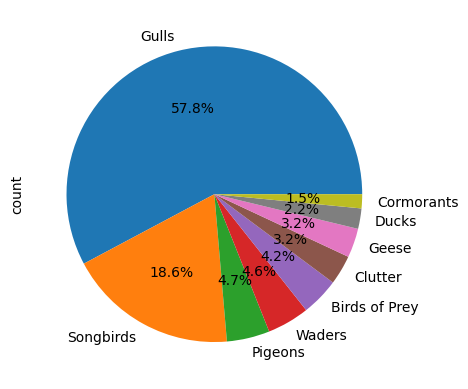

In [ ]:
import matplotlib.pyplot as plt

train_df['bird_group'].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

In [ ]:
from shapely import wkb

wkb_hex = train_df['trajectory'].iloc[0]
 
geom = wkb.loads(bytes.fromhex(wkb_hex))
coords = list(geom.coords)

coords

[(6.79934465, 53.45849494, 51.576, -32.3),
 (6.79955911, 53.45855682, 50.019, -31.9),
 (6.79974432, 53.45860298, 51.826, -26.3),
 (6.79993511, 53.45864817, 52.74, -26.0),
 (6.80013858, 53.4586728, 54.564, -37.8),
 (6.80036251, 53.45868946, 56.161, -37.3),
 (6.80053995, 53.45862705, 56.994, -36.5),
 (6.80055064, 53.45845121, 59.155, -38.0),
 (6.80074574, 53.45840345, 60.002, -39.7),
 (6.80097011, 53.45840502, 61.596, -36.7),
 (6.80117407, 53.45842036, 64.169, -35.2),
 (6.80136176, 53.45848945, 66.491, -22.1),
 (6.80153182, 53.45861544, 67.774, -33.0),
 (6.8016236, 53.45871828, 69.03, -24.6),
 (6.80174753, 53.45880143, 69.754, -25.2),
 (6.80191692, 53.45887956, 71.851, -29.8),
 (6.80210679, 53.4589564, 73.965, -29.1),
 (6.80228943, 53.45904181, 76.079, -25.5),
 (6.80243277, 53.45907539, 77.44, -36.7),
 (6.80263052, 53.45912817, 78.844, -35.3),
 (6.80283209, 53.45918778, 81.472, -29.2),
 (6.80325836, 53.45923708, 84.451, -27.9),
 (6.80358669, 53.45927139, 86.093, -37.9),
 (6.80383824, 53.

In [ ]:
def split_xyzm(wkb_hex):
    geom = wkb.loads(bytes.fromhex(wkb_hex))
    coords = list(geom.coords)

    xs, ys, zs, RCSs = zip(*coords)

    return pd.Series({
        "x": xs,
        "y":ys,
        "z":zs,
        "RCS":RCSs
    })

extra_train_cols = train_df['trajectory'].apply(split_xyzm)
extra_test_cols = test_df['trajectory'].apply(split_xyzm)

train_df = train_df.join(extra_train_cols)

test_df = test_df.join(extra_test_cols)

train_df['mean_RCS'] = train_df['RCS'].apply(np.mean)
test_df['mean_RCS'] = test_df['RCS'].apply(np.mean)

test_df

,timestamp_start_radar_utc,timestamp_end_radar_utc,trajectory,trajectory_time,radar_bird_size,airspeed,min_z,max_z,x,y,z,RCS,mean_RCS
track_id,,,,,,,,,,,,,
6868504,2023-09-12 07:32:03,2023-09-12 07:32:15,01020000E0E61000000C0000001CE392FCEB391B404F2D...,"[0.0, 1.01691, 2.0349, 3.04959, 4.06951, 5.089...",Flock,21.1292,42.711,49.101,"(6.80656428, 6.80662742, 6.80664912, 6.8067847...","(53.4487722, 53.44887828, 53.4490285, 53.44913...","(44.812, 46.457, 47.247, 48.343, 49.101, 47.17...","(-17.2, -14.1, -15.5, -13.3, -17.9, -14.0, -15...",-15.991667
6868536,2023-09-12 07:32:03,2023-09-12 07:32:19,01020000E0E61000000F0000002D667C46BF391B409163...,"[0.0, 1.02105, 2.0403, 3.06218, 4.08264, 5.106...",Flock,24.9480,39.892,45.495,"(6.80639372, 6.80618714, 6.80613205, 6.8059606...","(53.44873019, 53.44876988, 53.44890253, 53.449...","(44.276, 45.495, 44.043, 41.949, 41.399, 39.89...","(-26.2, -18.7, -14.5, -16.8, -26.8, -29.4, -23...",-20.246667
6868565,2023-09-12 07:32:03,2023-09-12 07:32:23,01020000E0E61000001400000019543CAA71391B409B92...,"[0.0, 1.02037, 2.04036, 3.0603, 4.0825, 5.1028...",Large bird,18.5307,42.994,50.100,"(6.80609766, 6.80591781, 6.80583634, 6.8057839...","(53.44850797, 53.44854181, 53.44868176, 53.448...","(46.432, 47.292, 45.567, 44.281, 42.994, 43.47...","(-18.1, -22.8, -19.8, -19.7, -20.0, -21.3, -16...",-17.785000
6868861,2023-09-12 07:32:03,2023-09-12 07:33:06,01020000E0E610000039000000E1600C388D391B40B1E7...,"[0.0, 1.01986, 3.0611, 4.08251, 5.10223, 7.147...",Large bird,17.7535,43.493,56.919,"(6.80620277, 6.80605568, 6.80574443, 6.8055876...","(53.44861454, 53.44864416, 53.44882874, 53.448...","(45.489, 47.393, 45.073, 43.763, 43.493, 45.95...","(-21.0, -21.9, -21.3, -26.8, -25.3, -22.4, -20...",-17.801754
6869275,2023-09-12 07:32:04,2023-09-12 07:34:00,01020000E0E61000006C0000000FC61DA99D391B40B9ED...,"[0.0, 2.04045, 3.0644, 4.08169, 5.10318, 6.124...",Flock,18.0350,38.364,68.100,"(6.80626549, 6.80610308, 6.8058727, 6.80590723...","(53.44882714, 53.44916909, 53.44935226, 53.449...","(45.722, 43.027, 39.501, 38.364, 41.91, 44.835...","(-21.2, -23.3, -19.1, -20.5, -16.6, -19.4, -26...",-19.841667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
589734589,2024-05-10 10:05:30,2024-05-10 10:05:51,01020000E0E610000013000000B497A75237381B4043E9...,"[0.0, 1.99119, 2.98708, 3.98369, 5.97631, 6.97...",Small bird,12.9431,96.301,110.376,"(6.80489854, 6.80494404, 6.80496649, 6.8049832...","(53.45126063, 53.45100345, 53.45087452, 53.450...","(100.033, 108.647, 109.282, 110.376, 108.935, ...","(-36.0, -30.3, -34.3, -25.9, -28.1, -31.7, -22...",-29.000000
589734601,2024-05-10 10:05:10,2024-05-10 10:05:52,01020000E0E61000002400000024E5F6E4C4371B406A10...,"[0.0, 0.994542, 1.98745, 2.98034, 5.95933, 6.9...",Medium bird,14.9002,69.182,117.652,"(6.80446203, 6.80444433, 6.80443615, 6.8044479...","(53.45357821, 53.45348594, 53.45337042, 53.453...","(114.432, 115.007, 115.37, 114.514, 116.176, 1...","(-17.3, -21.5, -14.7, -16.0, -20.3, -16.3, -24...",-23.794444
589735157,2024-05-10 10:04:53,2024-05-10 10:06:26,01020000E0E61000005300000020C18523E5321B407697...,"[0.0, 2.00354, 3.00567, 4.00863, 5.01071, 8.01...",Small bird,15.2171,8.736,60.906,"(6.79970222, 6.79954654, 6.79947132, 6.7993779...","(53.44823773, 53.44837646, 53.44846641, 53.448...","(22.975, 34.486, 28.157, 31.43, 31.809, 29.347...","(-20.0, -26.5, -25.7, -24.8, -28.1, -33.9, -42...",-32.086747


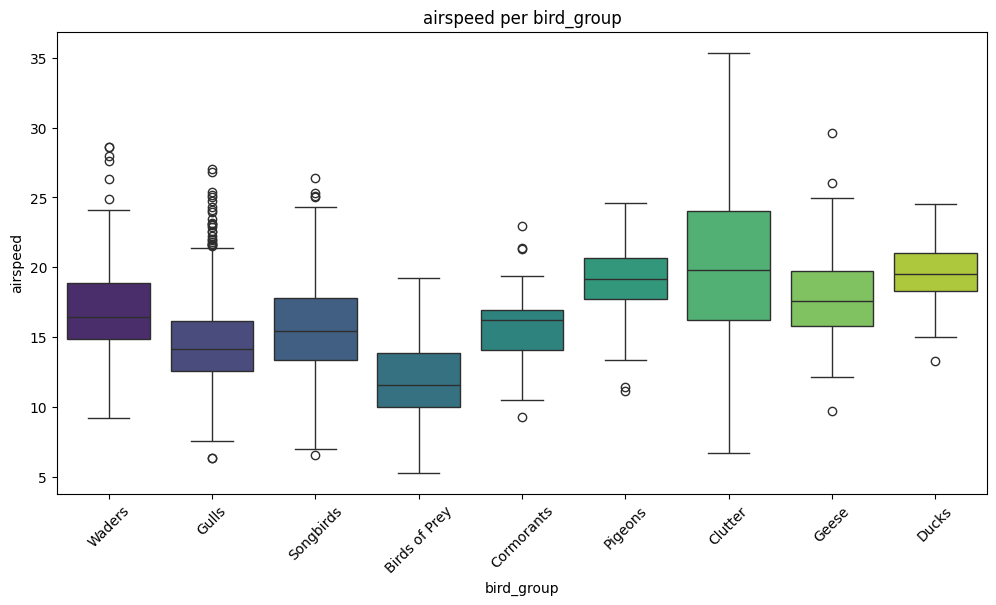

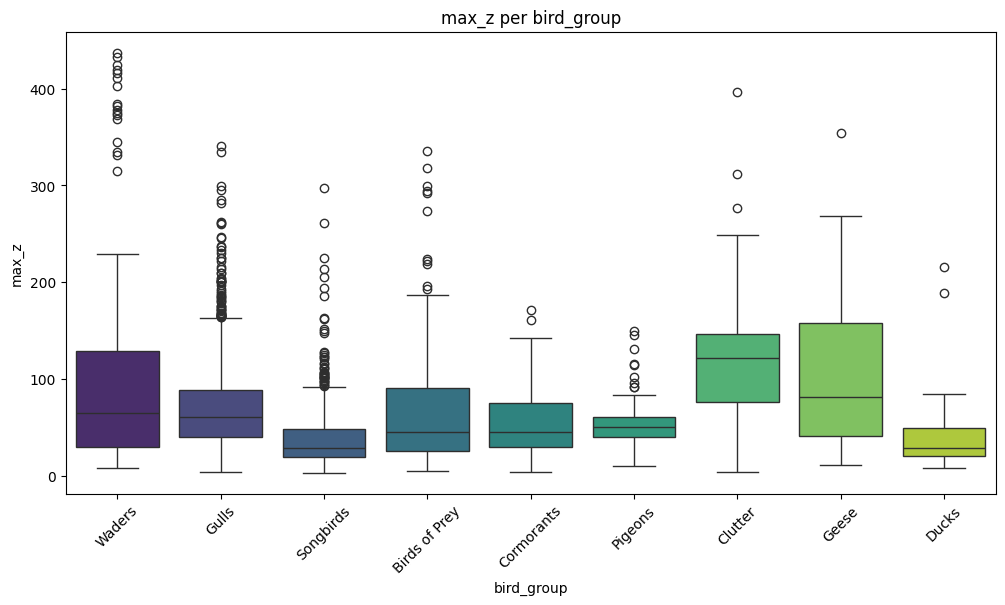

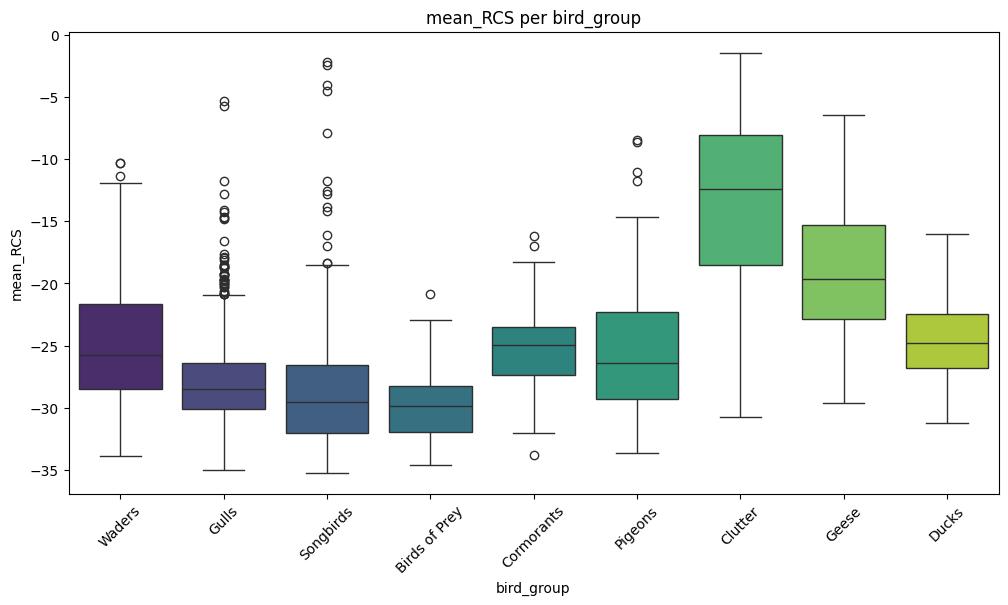

In [ ]:
import seaborn as sns

num_cols_to_plot = ['airspeed', 'max_z', 'mean_RCS']

for feat in num_cols_to_plot:
    plt.figure(figsize=(12,6))
    sns.boxplot(data=train_df, x='bird_group', y=feat, palette='viridis', hue='bird_group')
    plt.title(f"{feat} per bird_group")
    plt.xticks(rotation=45)
    plt.show()
    plt.close()

# Prepare features


In [ ]:
#model input X
#model targets y

features = ['airspeed', 'min_z', 'max_z', 'mean_RCS', 'radar_bird_size']

X = train_df[features]
X_test = test_df[features]

y = train_df['bird_group']

X

print(X_test)

           airspeed   min_z    max_z   mean_RCS radar_bird_size
track_id                                                       
6868504     21.1292  42.711   49.101 -15.991667           Flock
6868536     24.9480  39.892   45.495 -20.246667           Flock
6868565     18.5307  42.994   50.100 -17.785000      Large bird
6868861     17.7535  43.493   56.919 -17.801754      Large bird
6869275     18.0350  38.364   68.100 -19.841667           Flock
...             ...     ...      ...        ...             ...
589734589   12.9431  96.301  110.376 -29.000000      Small bird
589734601   14.9002  69.182  117.652 -23.794444     Medium bird
589735157   15.2171   8.736   60.906 -32.086747      Small bird
589735318   13.1801   8.565   65.829 -31.286364      Small bird
589735967   13.3897  47.974  144.923 -24.966327     Medium bird

[1872 rows x 5 columns]


In [ ]:
y

track_id
2537685             Waders
2538937              Gulls
2539560              Gulls
2541207          Songbirds
2541221          Songbirds
                 ...      
582320338          Clutter
582320867            Gulls
582320884            Gulls
582321034    Birds of Prey
582322274            Gulls
Name: bird_group, Length: 2601, dtype: object

# Setup the pipeline


In [ ]:
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer  
from imblearn.pipeline import Pipeline as ImbPipeline  
from imblearn.over_sampling import SMOTE
from sklearn.compose import make_column_selector
# numeric_transformer = Pipeline(steps=[
#     ('imputer', SimpleImputer(strategy='median')),
#     ('scaler', StandardScaler())
# ])


# preprocessor = ColumnTransformer(
#     [('cat', OneHotEncoder(), ['radar_bird_size'])],
#     remainder='passthrough'
# )

# pipeline = Pipeline([
#     ('preprocess', preprocessor),
#     ('model', HistGradientBoostingClassifier(random_state=42))
# ])

# Preprocessing for numeric columns: impute median then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical columns: impute most frequent then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include='number')),
        ('cat', categorical_transformer, make_column_selector(dtype_include='object'))
    ])

# Final pipeline: preprocessing -> SMOTE -> ensemble classifier
pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),                     # generates synthetic samples for minority class
    ('model', HistGradientBoostingClassifier(random_state=42))
])

# Cross validation

In [ ]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

split = list(cv.split(X, y))

for i, (train_idx, val_idx) in enumerate(split):
    print(f"fold {i+1} train: {len(train_idx)}, val:  {len(val_idx)}" )

fold 1 train: 2080, val:  521
fold 2 train: 2081, val:  520
fold 3 train: 2081, val:  520
fold 4 train: 2081, val:  520
fold 5 train: 2081, val:  520


# Training the model


In [ ]:
from sklearn.base import clone

classes = np.unique(y)

oof_preds = pd.DataFrame(0.0, index=X.index, columns=classes)

test_preds = np.zeros((len(X_test), len(classes)))

for i, (train_idx, val_idx) in enumerate(split):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_val = X.iloc[val_idx]
    y_val = y.iloc[val_idx]

    pipeline_fold = clone(pipeline)

    pipeline_fold.fit(X_train, y_train)

    val_preds = pipeline_fold.predict_proba(X_val)
    oof_preds.iloc[val_idx] = val_preds

    test_preds_fold = pipeline_fold.predict_proba(X_test)

    test_preds += test_preds_fold

    print(f"Trained fold{i+1}/{n_splits}!")
    

Trained fold1/5!
Trained fold2/5!
Trained fold3/5!
Trained fold4/5!
Trained fold5/5!


In [ ]:
oof_preds

,Birds of Prey,Clutter,Cormorants,Ducks,Geese,Gulls,Pigeons,Songbirds,Waders
track_id,,,,,,,,,
2537685,0.187057,0.000126,0.028459,0.000118,0.000046,0.544526,0.002683,0.131118,0.105868
2538937,0.843569,0.000010,0.001232,0.000005,0.000003,0.148017,0.000022,0.004498,0.002643
2539560,0.215130,0.000108,0.037023,0.000020,0.000050,0.346682,0.000117,0.396658,0.004211
2541207,0.001743,0.000004,0.000490,0.000011,0.000008,0.018050,0.000061,0.977593,0.002041
2541221,0.008765,0.000009,0.043166,0.000011,0.000013,0.141116,0.000617,0.803371,0.002932
...,...,...,...,...,...,...,...,...,...
582320338,0.000202,0.137966,0.000134,0.317844,0.001300,0.016590,0.000054,0.523535,0.002376
582320867,0.314846,0.000107,0.137238,0.000912,0.000070,0.150688,0.000542,0.136986,0.258611
582320884,0.000769,0.000016,0.000402,0.237469,0.002012,0.242922,0.000486,0.003654,0.512268


In [ ]:
import pandas as pd
import sklearn.metrics

def score(
    solution: pd.DataFrame, 
    submission: pd.DataFrame, 
) -> float:
    #Takes in two pandas dataframe and computes the Macro-averaged Average Precision Score
   
    # Ensure all required columns are present
    needed_columns = [
        "Clutter", 
        "Cormorants", 
        "Pigeons", 
        "Ducks", 
        "Geese", 
        "Gulls", 
        "Birds of Prey", 
        "Waders", 
        "Songbirds",
    ]
    
    # Reorder solution and submission columns/rows to match exactly
    solution = solution.loc[solution.index, needed_columns]
    submission = submission.loc[solution.index, needed_columns]

    
    # Compute the Average Precision score for all required columns
    bird_score = sklearn.metrics.average_precision_score(
        solution[needed_columns],
        submission[needed_columns],
        average='macro'
    )

    return bird_score

In [ ]:
# Get local OOF CV score
solution_df = (
    train_df
    .groupby(["track_id", "bird_group"])
    .size()
    .unstack(fill_value=0)
)

oof_score = score(solution_df, oof_preds)

print(f"OOF score: {oof_score}")

OOF score: 0.3868618755031489


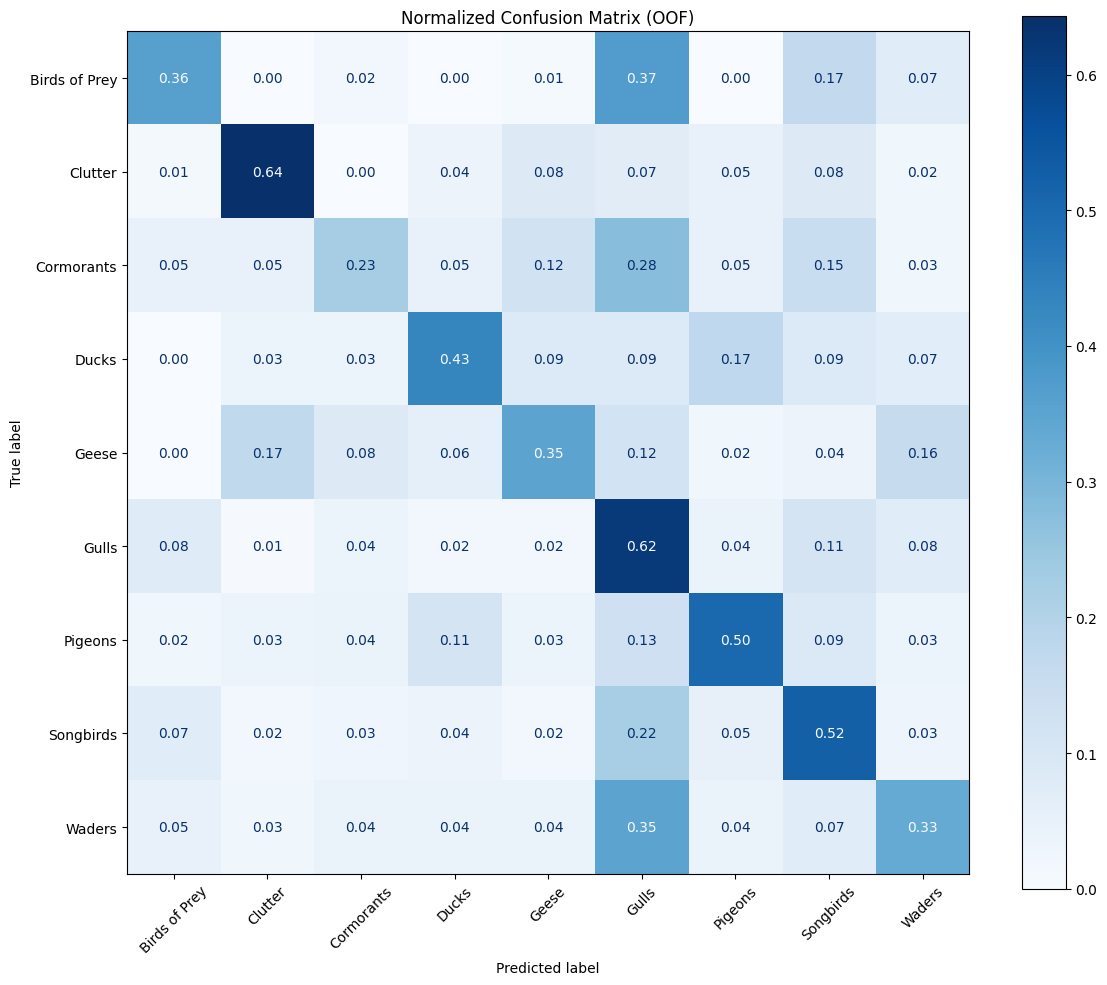

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Convert OOF probabilities to hard class labels
y_pred_oof = classes[np.argmax(oof_preds, axis=1)]

# Plot Normalized Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y, 
    y_pred_oof, 
    display_labels=classes,
    cmap="Blues",
    normalize='true',
    values_format=".2f",
    xticks_rotation=45,
    ax=ax
)

plt.title("Normalized Confusion Matrix (OOF)")
plt.tight_layout()
plt.show()
plt.close()


In [ ]:
submission_df = pd.DataFrame(
    test_preds / n_splits,
    index=X_test.index,
    columns=classes
)

submission_df.to_csv('submission.csv')

print("Saved to submission.csv")

!head submission.csv

Saved to submission.csv
track_id,Birds of Prey,Clutter,Cormorants,Ducks,Geese,Gulls,Pigeons,Songbirds,Waders
6868504,2.4733423081313038e-05,6.158229437426476e-05,7.866284837514649e-05,0.00016136838725258002,0.024197625730790633,0.002515703232413753,0.970829300731715,0.0009371293387977377,0.0011938940131995459
6868536,7.139844255428842e-05,0.0012763051121553535,0.00016009406058471856,0.003663294595905351,0.05637263664641421,0.2087364637031571,0.7100025222697052,0.01468444846505392,0.005032836704469876
6868565,2.600291494295978e-06,0.0011327821259376168,0.005113330563474276,0.0054576432334499875,0.0025113239348602337,0.0001390398906377447,0.9854268888223776,9.759394465415222e-05,0.00011879719311418962
6868861,1.494404625768997e-05,0.0005742435261223938,0.07227261250265013,0.00015217534281097383,0.012153823056955563,0.0005326218570194727,0.9138592967547448,0.00015687183957176494,0.0002834110738672874
6869275,5.166226210408089e-05,0.000268510250965453,0.0005369478724825086,0.00022236614572